# Entrenamiento Baseline y Comparación de Modelos — NeuroRisk

**Ticket #10 (Micro-proyecto, Entrega 2):** entrenamiento baseline de 3 algoritmos y logging de métricas/artefactos en MLflow.

Este notebook **no reimplementa** el pipeline de entrenamiento — importa directamente de `src/models/train.py` (la misma lógica que corre `python -m src.models.train` y que loguea a MLflow) para que el reporte y la exploración visual usen exactamente el mismo código que la ejecución reproducible, sin duplicar lógica.

Cubre:
1. Carga de `data/features/features.csv` y split train/test
2. Entrenamiento de los 3 modelos (Logistic Regression, Random Forest, XGBoost) con el mismo pipeline de preprocesamiento (imputación + `RobustScaler`, ajustado solo sobre train)
3. Comparación de métricas (F1, ROC-AUC, Recall) en holdout y en cross-validation (`StratifiedKFold(5)`)
4. Curvas ROC y matrices de confusión
5. Distribución de métricas por fold (relevante dado el tamaño chico del dataset, n=89)

In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline

from src.models.train import (
    RANDOM_STATE,
    build_models,
    build_preprocessor,
    evaluate_holdout,
    load_dataset,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

C:\Users\USUARIO\Documents\ARCHIVOS\Documents\Maestria\MLOps\Microproyecto\Microproyecto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga de datos y split

Mismo split que usa `src/models/train.py` (`test_size=0.2`, `stratify=y`, `random_state=42`) para que las métricas de este notebook sean comparables con las que quedan logueadas en MLflow.

In [2]:
X, y = load_dataset()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} filas, Test: {X_test.shape[0]} filas")
print(f"Balance target train: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Balance target test:  {y_test.value_counts(normalize=True).to_dict()}")

Train: 71 filas, Test: 18 filas
Balance target train: {1: 0.5211267605633803, 0: 0.4788732394366197}
Balance target test:  {1: 0.5555555555555556, 0: 0.4444444444444444}


## 2. Entrenar los 3 modelos

Cada modelo usa su propio `Pipeline` (preprocesamiento + modelo), ajustado únicamente sobre `X_train`. Se guardan las predicciones/probabilidades de test y los scores de cross-validation por fold, para las visualizaciones de las siguientes secciones.

In [3]:
preprocessor = build_preprocessor(X)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fitted_pipelines = {}
holdout_results = {}
cv_fold_scores = []

for name, model in build_models().items():
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])

    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={"f1": "f1", "roc_auc": "roc_auc", "recall": "recall"},
    )
    for metric in ["f1", "roc_auc", "recall"]:
        for fold_score in cv_scores[f"test_{metric}"]:
            cv_fold_scores.append(
                {"model": name, "metric": metric, "score": fold_score}
            )

    pipeline.fit(X_train, y_train)
    fitted_pipelines[name] = pipeline
    holdout_results[name] = evaluate_holdout(pipeline, X_test, y_test)

cv_fold_scores_df = pd.DataFrame(cv_fold_scores)
print("Modelos entrenados:", list(fitted_pipelines.keys()))

Modelos entrenados: ['logistic_regression', 'random_forest', 'xgboost']


## 3. Comparación de métricas (holdout)

In [4]:
results_df = pd.DataFrame(holdout_results).T.round(3)
results_df = results_df.sort_values("test_f1", ascending=False)
results_df

,test_f1,test_roc_auc,test_recall
logistic_regression,0.667,0.587,0.7
xgboost,0.632,0.625,0.6
random_forest,0.444,0.456,0.4


## 4. Curvas ROC (test set)

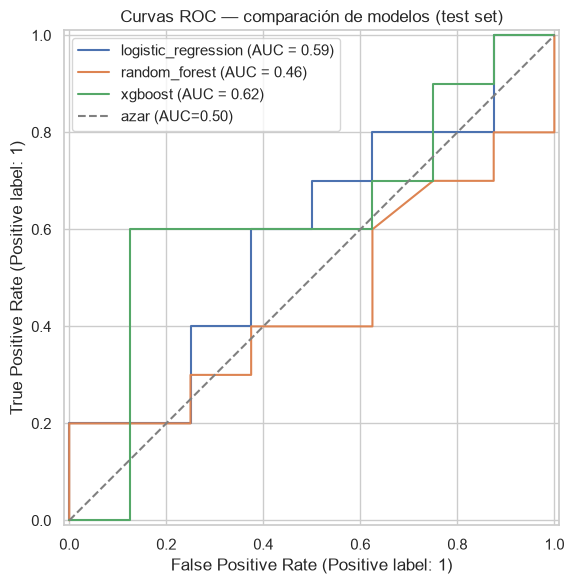

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, pipeline in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="azar (AUC=0.50)")
ax.set_title("Curvas ROC — comparación de modelos (test set)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Matrices de confusión (test set)

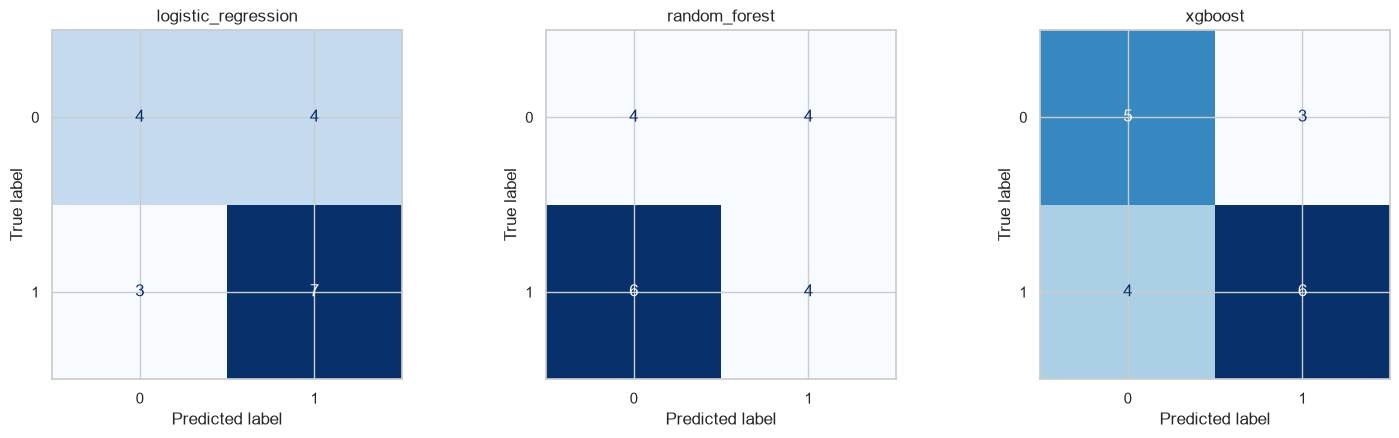

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, pipeline) in zip(axes, fitted_pipelines.items(), strict=True):
    ConfusionMatrixDisplay.from_estimator(
        pipeline, X_test, y_test, ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 6. Distribución de métricas en cross-validation

Con n=89 (~71 en train), un único holdout de test (18 filas) deja muy pocas muestras para confiar en un solo número. Este boxplot muestra la variabilidad entre los 5 folds de `StratifiedKFold` sobre train — más informativo que solo la media.

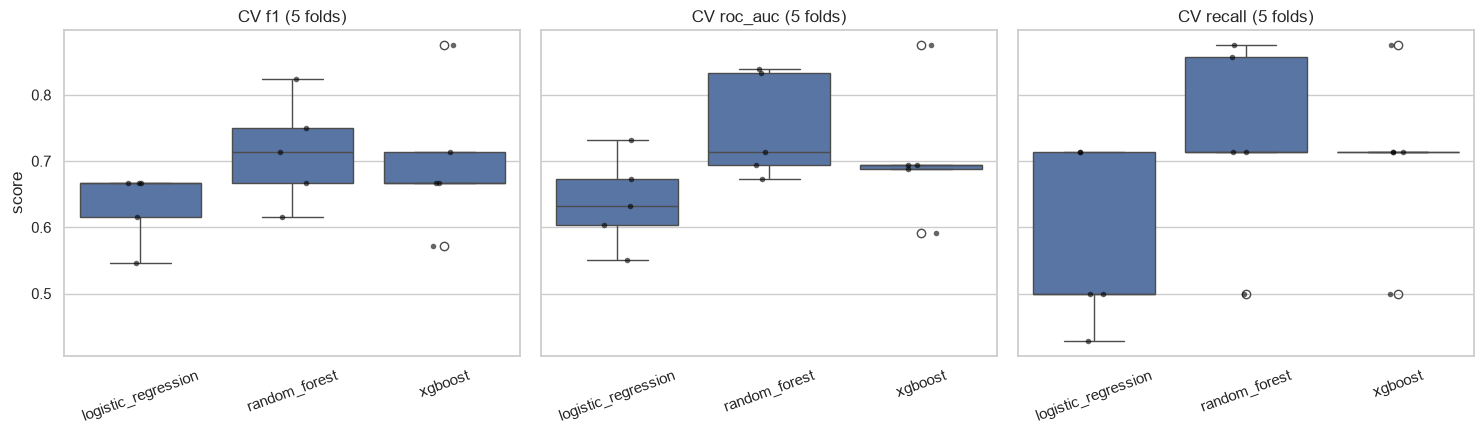

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, metric in zip(axes, ["f1", "roc_auc", "recall"], strict=True):
    subset = cv_fold_scores_df[cv_fold_scores_df["metric"] == metric]
    sns.boxplot(data=subset, x="model", y="score", ax=ax, color="#4C72B0")
    sns.stripplot(
        data=subset, x="model", y="score", ax=ax, color="black", size=4, alpha=0.6
    )
    ax.set_title(f"CV {metric} (5 folds)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## Resumen para el reporte

- Los 3 modelos (Logistic Regression, Random Forest, XGBoost) quedan logueados en MLflow (hiperparámetros, métricas de CV y holdout, y el pipeline completo como artefacto `.joblib`) al correr `python -m src.models.train` — este notebook usa exactamente el mismo código para las comparaciones de arriba.
- Con n=89, la variabilidad entre folds (sección 6) es considerable — cualquier conclusión sobre "qué modelo es mejor" debe tomarse como preliminar, no como benchmark definitivo. Este es un baseline (ticket #10); ajuste de hiperparámetros queda para un ticket posterior.
- Completar tras revisar los resultados: ¿cuál modelo se ve más prometedor?, ¿hay señales de overfitting (CV alto pero holdout bajo, o viceversa)?, ¿alguna métrica particularmente débil en algún modelo (ej. Recall bajo, relevante clínicamente porque significa no detectar casos con alteración real)?